In [1]:
!pip install icecream

In [2]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd /content/drive/MyDrive

/content/drive/MyDrive


In [5]:
# only need to clone once
!git clone https://github.com/fedhere/snidpy

fatal: destination path 'snidpy' already exists and is not an empty directory.


In [6]:
cd /content/drive/MyDrive/ABC-SN/code

/content/drive/MyDrive/ABC-SN/code


In [7]:
sys.path.insert(0, "content/drive/MyDrive/ABC-SN/code")
from data_degrading import degrade_spectrum
import abcsn_training
import abcsn_config

sys.path.insert(0, "/content/drive/MyDrive/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw
from logwave import log_rebin

# Classifying Supernova Spectra With ABC-SN

# 1. Load ABC-SN

The file `ABCSN.keras` is not hosted on GitHub because it is too large of a file. You must download it from Zenodo [here](https://zenodo.org/records/16620817). Place it in `abcsn/` and ensure that it is called `ABCSN.keras`. `ABCSN.keras` has been added to `.gitignore`.

In [8]:
abcsn = keras.models.load_model("/content/drive/MyDrive/ABC-SN/abcsn/ABCSN.keras", compile=False)

# 2. Data

Importing the data from Milligan et al.


In [9]:
cd /content/drive/MyDrive/ABC-SN/milligan_data

/content/drive/MyDrive/ABC-SN/milligan_data


In [10]:
# only unzip once
# !unzip classcomp_sample14.zip #smallest folder

In [11]:
# just taking 10 for now
# file names and location in the drive
filename = sorted(glob.glob("/content/drive/MyDrive/ABC-SN/milligan_data/kinney_sample14/*"))
# filename

In [56]:
file_info = [name.split("/")[-1] for name in filename]

## Extracting information from the file name:
[Host Morphology][True SN Class]Smag[SN Fibre Mag.]Gmag[Host Fibre Mag.]z[Redshift]texp[Exposure Time in Mins].txt

In [20]:
host_types = ["elliptical", "s0", "sa", "sb", "sc", "starb1", "starb1", "starb2", "starb3", "starb4", "starb5", "starb6"]
# needs to go longest to shortest so it doesnt find II instead of IIb
# there's Iap?? not mentioned in paper

sn_class_dict = {"IIb": "IIb",
                 "IIn": "IIn",
                 "II_": "II",
                 "Iap": "Iap",
                 "Ia_": "Ia",
                 "Ic_": "Ic",
                 "Ib_": "Ib",
                 "SL_": "SL",
                 "TDE": "TDE",
                 "CRT": "CaRT"}

In [50]:
# file_info
file_info[0]

'ellipticalIa_Smag19.012Gmag21.234z0.088028texp40.781.txt'

In [65]:
def get_host_sn_type(fileinfo):
  """Extracts the host morphology and true SN class from the filename.
  filename format: [Host Morphology][True SN Class]Smag...
  """
  host = None
  sn = None
  info = fileinfo.split("Smag")[0]
  host = info[:-3]
  assert host in host_types, "Host type not in list: {}".format(fileinfo[0])

  sn = info[-3:]
  assert sn in sn_class_dict.keys(), "SN type not in list: {}".format(fileinfo[0])
  return host, sn_class_dict[sn]

def get_redshift(fileinfo):
  """Extracts the redshift from the filename.
  filename format: ...z[Redshift]texp...
  """
  redshift = fileinfo.split("z")[1].split("texp")[0]
  redshift = float(redshift)
  assert redshift > 0, "Redshift must be positive: {}".format(fileinfo[0])
  assert redshift < 3, "Redshift must be less than 3: {}".format(fileinfo[0]) # based on this dataset specifically
  return redshift

def get_SN_mag(fileinfo):
  """Extracts the SN Fibre Magnitude from the filename.
  filename format: ...Smag[SN Fibre Mag.]Gmag...
  """
  Smag = fileinfo.split("Smag")[1].split("Gmag")[0]
  Smag = float(Smag)
  return Smag

def get_host_mag(fileinfo):
  """Extracts the Host Fibre Magnitude from the filename.
  filename format: ...Gmag[Host Fibre Mag.]z...
  """
  Gmag = fileinfo.split("Gmag")[1].split("z")[0]
  Gmag = float(Gmag)
  return Gmag

def get_filename_info(filename):
  """Extracts all the information from the filename.
  filename format: [Host Morphology][True SN Class]Smag[SN Fibre Mag.]Gmag[Host Fibre Mag.]z[Redshift]texp[Exposure Time in Mins].txt
  """
  host, sn_type = get_host_sn_type(filename)
  redshift = get_redshift(filename)
  Smag = get_SN_mag(filename)
  Gmag = get_host_mag(filename)
  return host, sn_type, redshift, Smag, Gmag

In [66]:
df_metadata = pd.DataFrame(filename, columns=["filename"])
df_metadata[["host", "sn_type", "redshift", "SN_mag", "host_mag"]] = [get_filename_info(info) for info in file_info]


array([[<Axes: title={'center': 'redshift'}>,
        <Axes: title={'center': 'SN_mag'}>],
       [<Axes: title={'center': 'host_mag'}>, <Axes: >]], dtype=object)

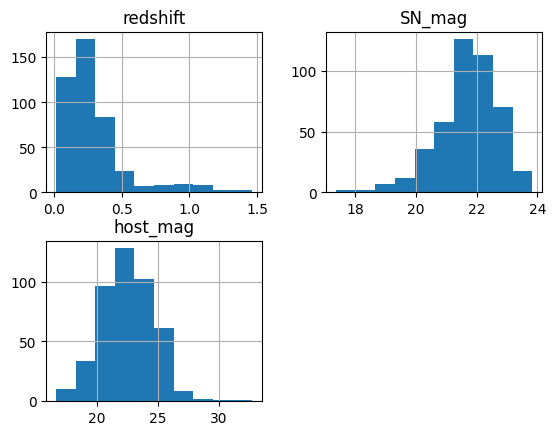

In [83]:
df_metadata[ "host_mag"] = df_metadata[ "host_mag"].astype(float)
df_metadata[ "redshift"] = df_metadata[ "redshift"].astype(float)
df_metadata[ "SN_mag"] = df_metadata[ "SN_mag"].astype(float)
df_metadata.hist()

## processing data

Each spectrum contains five columns, wavelength (0), flux (1), flux error (2), flux with no sky subtraction (3), flux error with no sky subtraction (4).

In [17]:
# based on the code used in snidpy logwave to served the different file structure as well as not needed to reread in the spectrum

def simplified_process_spectrum(wave, flux): #-> Dict:
    """Process all epochs for a supernova."""

    from logwave import SNIDConfig

    # Initialize arrays
    nw = SNIDConfig().nw
    flog = np.zeros(nw)
    fnorm = np.zeros(nw)
    fmean = [0]
    nknot = np.zeros(1, dtype=int)

    # Setup log wavelength grid
    dwlog = np.log(SNIDConfig().w1 / SNIDConfig().w0) / nw
    wlog = SNIDConfig().w0 * np.exp(np.arange(nw + 1) * dwlog)

    # Process each epoch
    most_knots = 0
    # Read spectrum


    assert len(wave) > 0, "no data"


    # Rebin to log scale
    flog = log_rebin(wave, flux, nw, SNIDConfig().w0, SNIDConfig().w1)

    # Normalize (remove continuum)
    fnorm, l1, l2, nknot, xknot, yknot = meanzero(flog)
    #print("here", fnorm)
    most_knots = max(most_knots, nknot)

    # Apodize
    #fnorm = apodize(fnorm, 10,
    #                      -10, self.config.percent)

    # Calculate mean flux for scaling
    fmean = np.mean(flog)
    flog = flog / fmean

    # Prepare output
    output = {
        'wlog': wlog,
        'flog': flog,
        'fnorm': fnorm,
        'fmean': fmean,
        'nknot': nknot
    }

    return output

In [18]:
def process_files(filename, wmin, wmax, plot_spectra = True, verbose = True):

  try:
    sep = " " # Define separator for reading data
    s = pd.read_csv(filename, sep=sep, header=None, comment="#") # Read the spectrum data
    if plot_spectra:
      display(s.head())

    # Read and plot the original spectrum
    wave, flux = s[0], s[1]
    # Apply wavelength mask
    mask = (wave >= wmin) & (wave <= wmax)
    wave, flux = wave[mask], flux[mask]
    sp = wave, flux

    if plot_spectra:
      name = filename.split("/")[-1]
      s.plot(x=0, y=1)
      plt.title(name)
      plt.plot(sp[0], sp[1], 'k-.', alpha=0.5)
      plt.show()
    if verbose:
      print("READ IN OK")


    # Process the spectrum using logwave (lw) module functions
    processedsn = simplified_process_spectrum(wave, flux)
    if verbose:
      print("processed")
    # print(processedsn)

    # Extract and normalize flux values
    # this is adjusting the wavelength bins to take the center value
    wlog0 = processedsn["wlog"][0:-1] + np.diff(processedsn["wlog"]) / 2
    flog = processedsn["fnorm"]
    # print(flog.mean())

    # select correct range
    select = (wlog0 < wmin) | (wlog0 > wmax)

    # normalize log flux
    flog = (flog - flog[~select].mean()) / flog[~select].std()
    flog[select] = 0

    # Degrade the spectrum
    spd = degrade_spectrum(100,
        wlog0,
        flog
        )

    # Plot the processed and degraded spectra
    if plot_spectra:
      plt.title(name)
      plt.plot(wlog0, flog)
      plt.plot(spd[1], spd[2])

    # return processed spectrum data and extract metadata
    X = np.array([spd[2]])
    X = X.reshape(1,X.shape[1])

    wvl = spd[1]

    return wvl, X

  except Exception as e:
    print(filename, "FAILED")
    print(e)

,0,1,2,3,4
0,3671.50,-1.540120e-17,4.191180e-17,-3.098850e-18,4.191180e-17
1,3671.75,-2.458530e-17,4.182730e-17,-1.228830e-17,4.182730e-17
2,3672.00,-3.491330e-18,4.174410e-17,8.799890e-18,4.174410e-17
3,3672.25,3.297310e-17,4.166410e-17,4.526480e-17,4.166410e-17
4,3672.50,2.918540e-17,4.158060e-17,4.147270e-17,4.158060e-17


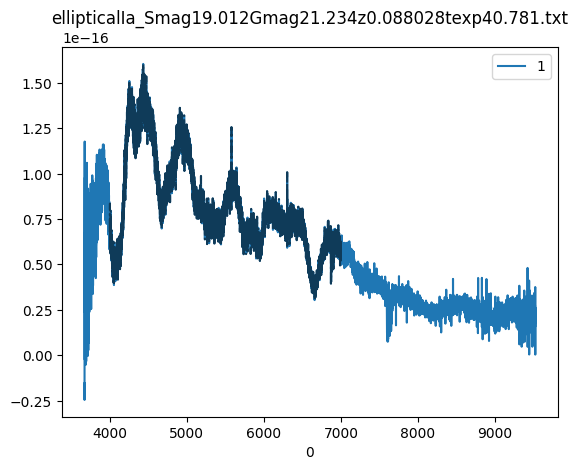

READ IN OK
meanzero
processed


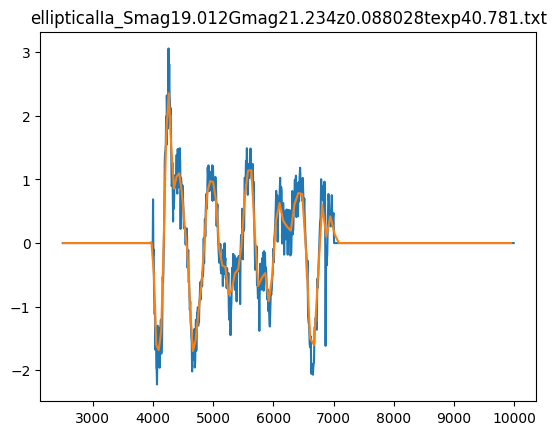

In [19]:
# test run
wvl, X = process_files(filename[0], 4000, 7000, plot_spectra = True)

In [20]:
# used:
# abcsn_config.SN_Stypes_int_to_str
# to make the dictionary corresponding to the labels used above
# may just want to change the above to use the same strings as int_to_str function
sn_ID_dict ={"Ia": 0,
          "Iax": 4,
          "Ic": 10,
          "Ib": 6,
          "II": 13, # IIP = type 2 plateau = normal
          "IIb": 8,
          "IIc": 10,
          "IIn": 15,
          "SL": None,
          "TDE": None,
          "CRT": None
          }

In [21]:
num_wvl = 139
num_classes = 10
dat_size = len(df_metadata)
plots = False

X_all = np.zeros((dat_size, 1, num_wvl))
Y_IDs = np.zeros((dat_size)) # classification as the float classifier

for i in tqdm(range(dat_size)):
  wvl, X = process_files(filename[i], 4000, 7000, plot_spectra = plots, verbose=False)
  X_all[i] = X
  # dont save wvl as all are the same

  try:
    Y_IDs[i] = sn_ID_dict[df_metadata.sn_type[i]]

  except Exception as e:
    print(df_metadata.sn_type[i], i)
    raise e


df_metadata["sn_ID"] = Y_IDs

# add option to save the data here


  0%|          | 0/444 [00:00<?, ?it/s]

meanzero


  0%|          | 1/444 [00:00<02:16,  3.24it/s]

meanzero


  0%|          | 2/444 [00:00<02:15,  3.26it/s]

...

meanzero
meanzero


100%|█████████▉| 443/444 [01:21<00:00,  4.55it/s]

meanzero


100%|██████████| 444/444 [01:22<00:00,  5.41it/s]

meanzero


# 3. Predict

1. `X` is your array of spectra to classify.
2. `P` is your array of output probabilities of each of the 10 classes.
3. `P_argmax` is your array of final predictions for each spectra in `X`. Class IDs defined from 0-10.
4. `P_IDs` is your array of final predictions for each spectra in `X`. Class IDs defined from 0-16.
5. `P_str` is the final SN subtype prediction for each spectra in `X`.

In [22]:
X = X_all.copy()
P = abcsn.predict(X, verbose=0)
P_argmax = np.argmax(P, axis=1)

In [23]:
index = ~np.isnan(Y_IDs)

cr = (classification_report(
    Y_IDs[index],
    P_argmax[index],
    labels=list(abcsn_config.SN_Stypes_int_to_str.keys()),
    target_names=list(abcsn_config.SN_Stypes_int_to_str.values())
    ))

print(cr)

              precision    recall  f1-score   support

     Ia-norm       0.60      0.01      0.02       275
      Ia-91T       0.00      0.00      0.00         0
     Ia-91bg       0.00      0.00      0.00         0
      Ia-csm       0.00      0.00      0.00         0
         Iax       0.00      0.00      0.00         0
      Ia-pec       0.00      0.00      0.00         0
     Ib-norm       0.00      0.00      0.00         7
         Ibn       0.00      0.00      0.00         0
         IIb       0.05      0.06      0.05        16
      Ib-pec       0.00      0.00      0.00         0
     Ic-norm       0.00      0.00      0.00         7
    Ic-broad       0.00      0.00      0.00         0
      Ic-pec       0.00      0.00      0.00         0
         IIP       0.00      0.00      0.00        63
         IIL       0.00      0.00      0.00         0
         IIn       0.00      0.00      0.00        25
      II-pec       0.00      0.00      0.00         0

    accuracy              

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

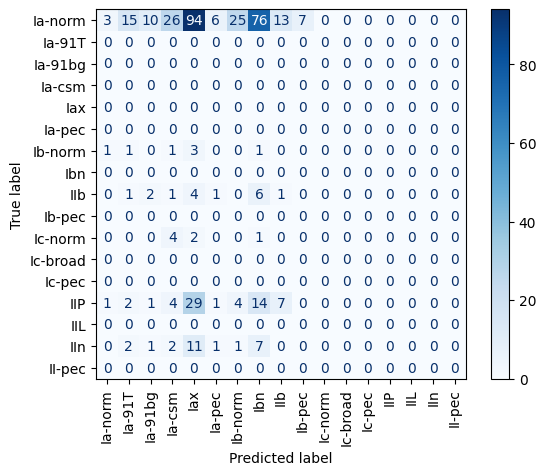

In [24]:
ConfusionMatrixDisplay.from_predictions(Y_IDs[index],
    P_argmax[index],
    labels=list(abcsn_config.SN_Stypes_int_to_str.keys()),
    display_labels=list(abcsn_config.SN_Stypes_int_to_str.values()),
    xticks_rotation = 'vertical',
    cmap=plt.cm.Blues
    )

# chech what is 1a
# try one class at a time

In [25]:
df_metadata.sn_type.value_counts()

,count
sn_type,
Ia,275
II,63
SL,45
IIn,25
IIb,16
Ib,7
Ic,7
TDE,6


In [26]:
df_metadata # get magnitudes, redshift, #may have to train on redshift

,filename,host,sn_type,redshift,sn_ID
0,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,elliptical,Ia,0.088028,0.0
1,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,elliptical,Ia,0.122000,0.0
2,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,elliptical,Ia,0.236060,0.0
3,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,elliptical,Ia,0.163130,0.0
4,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,elliptical,Ia,0.223470,0.0
...,...,...,...,...,...
439,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,sc,TDE,0.153390,NaN
440,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,starb1,TDE,0.024836,NaN
441,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,starb5,TDE,0.065149,NaN
442,/content/drive/MyDrive/ABC-SN/milligan_data/ki...,starb5,TDE,0.270180,NaN
